In [63]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [64]:
load = pd.read_csv('../data/load.csv', sep= ';')
solar = pd.read_csv('../data/solar.csv', sep=';')
wind = pd.read_csv('../data/wind.csv',sep=';')

In [65]:
for name, df in [("load", load), ("solar", solar), ("wind", wind)]:
    print(name, df.shape)
    print(df.head(3))
    df.info()
    print()

load (105216, 10)
                    Datetime Resolution code  Total Load  \
0  2025-08-08T06:30:00+02:00           PT15M     7820.38   
1  2025-08-08T06:00:00+02:00           PT15M     7785.68   
2  2025-08-08T03:45:00+02:00           PT15M     6965.65   

   Most recent forecast  Most recent P10  Most recent P90  \
0               7847.42          7648.31          8046.53   
1               7635.63          7441.92          7829.33   
2               7005.80          6808.28          7203.31   

   Day-ahead 6PM forecast  Day-ahead 6PM P10  Day-ahead 6PM P90  \
0                 7810.54            7544.17            8076.91   
1                 7589.01            7330.20            7847.83   
2                 7054.18            6790.34            7318.02   

   Week-ahead forecast  
0              7808.97  
1              7582.11  
2              7020.48  
<class 'pandas.DataFrame'>
RangeIndex: 105216 entries, 0 to 105215
Data columns (total 10 columns):
 #   Column                

In [66]:
load_clean = load[["Datetime", "Total Load"]].rename(columns={"Total Load": "load_mw"})

solar_clean = (
    solar.groupby("Datetime", as_index=False)["Measured & Upscaled"]
    .sum()
    .rename(columns={"Measured & Upscaled": "solar_mw"})
)

wind_clean = (
    wind.groupby("Datetime", as_index=False)["Measured & Upscaled"]
    .sum()
    .rename(columns={"Measured & Upscaled": "wind_mw"})
)

# Convert Datetime from text to an actual datetime type
for df in [load_clean, solar_clean, wind_clean]:
    df["Datetime"] = pd.to_datetime(df["Datetime"], utc=True)

print(load_clean.shape, solar_clean.shape, wind_clean.shape)
load_clean.head()
print()
load_clean.info()

(105216, 2) (212256, 2) (411932, 2)

<class 'pandas.DataFrame'>
RangeIndex: 105216 entries, 0 to 105215
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   Datetime  105216 non-null  datetime64[us, UTC]
 1   load_mw   105213 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(1)
memory usage: 1.6 MB


In [67]:
print(f'min_data_load: {load_clean.min()['Datetime']}')
print(f'max_data_load: {load_clean.max()['Datetime']}')
print()
print(f'min_data_solar: {solar_clean.min()['Datetime']}')
print(f'max_data_solar: {solar_clean.max()['Datetime']}')
print()
print(f'min_data_wind: {wind_clean.min()['Datetime']}')
print(f'max_data_wind: {wind_clean.max()['Datetime']}')

min_data_load: 2022-12-31 23:00:00+00:00
max_data_load: 2025-12-31 22:45:00+00:00

min_data_solar: 2020-08-31 22:00:00+00:00
max_data_solar: 2026-09-20 21:45:00+00:00

min_data_wind: 2014-12-31 23:00:00+00:00
max_data_wind: 2026-09-30 21:45:00+00:00


In [68]:
start = '2023-01-01'
end = '2025-12-31'

load_clean = load_clean[(load_clean['Datetime'] >= start) & (load_clean['Datetime']<= end)]
solar_clean = solar_clean[(solar_clean['Datetime'] >= start) & (solar_clean['Datetime'] <= end)]
wind_clean = wind_clean[(wind_clean['Datetime'] >= start )&(wind_clean['Datetime'] <= end)]

print(load_clean.shape, solar_clean.shape, wind_clean.shape)

(105121, 2) (105121, 2) (105121, 2)


In [69]:
df = load_clean.merge(solar_clean, on='Datetime',how='inner')
df = df.merge(wind_clean, on='Datetime', how='inner')

print(df.shape)
df.head()

(105121, 4)


,Datetime,load_mw,solar_mw,wind_mw
0,2025-08-08 04:30:00+00:00,7820.38,16.439,790.48
1,2025-08-08 04:00:00+00:00,7785.68,0.000,988.90
2,2025-08-08 01:45:00+00:00,6965.65,0.000,1526.33
3,2025-08-08 00:45:00+00:00,7007.51,0.000,1901.91
4,2025-08-08 00:30:00+00:00,7063.54,0.000,1909.90


In [70]:
df['hour'] = df['Datetime'].dt.hour
df['weekday'] = df['Datetime'].dt.day_name()
df['month']= df['Datetime'].dt.month
df['renewable_mw'] = df['solar_mw'] + df['wind_mw']
df['renewable_share_pct'] = (df['renewable_mw']/df['load_mw']*100).round(1)
df.head()

,Datetime,load_mw,solar_mw,wind_mw,hour,weekday,month,renewable_mw,renewable_share_pct
0,2025-08-08 04:30:00+00:00,7820.38,16.439,790.48,4,Friday,8,806.919,10.3
1,2025-08-08 04:00:00+00:00,7785.68,0.000,988.90,4,Friday,8,988.900,12.7
2,2025-08-08 01:45:00+00:00,6965.65,0.000,1526.33,1,Friday,8,1526.330,21.9
3,2025-08-08 00:45:00+00:00,7007.51,0.000,1901.91,0,Friday,8,1901.910,27.1
4,2025-08-08 00:30:00+00:00,7063.54,0.000,1909.90,0,Friday,8,1909.900,27.0


In [71]:
conn = sqlite3.connect('../data/elia.db')
df.to_sql('energy', conn, if_exists='replace', index=False)
conn.close()

print('saved tot elia.db')

saved tot elia.db


In [72]:
conn = sqlite3.connect('../data/elia.db')

In [73]:
query ="""
SELECT
    hour,
    ROUND(AVG(load_mw),1) AS avg_load,
    ROUND(AVG(solar_mw),1) AS avg_solar,
    ROUND(AVG(wind_mw),1) AS avg_wind
FROM energy
GROUP BY hour
ORDER BY hour
"""

In [74]:
hourly = pd.read_sql(query, conn)
hourly

,hour,avg_load,avg_solar,avg_wind
0,0,7726.9,0.0,1504.6
1,1,7568.0,0.0,1482.7
2,2,7534.4,0.0,1463.8
3,3,7683.3,2.8,1453.8
4,4,8130.3,133.8,1446.2
5,5,8798.4,680.7,1433.9
6,6,9378.1,1823.7,1413.8
7,7,9803.4,3611.8,1393.1
8,8,10040.5,5763.0,1380.3
9,9,10163.9,7695.7,1379.6


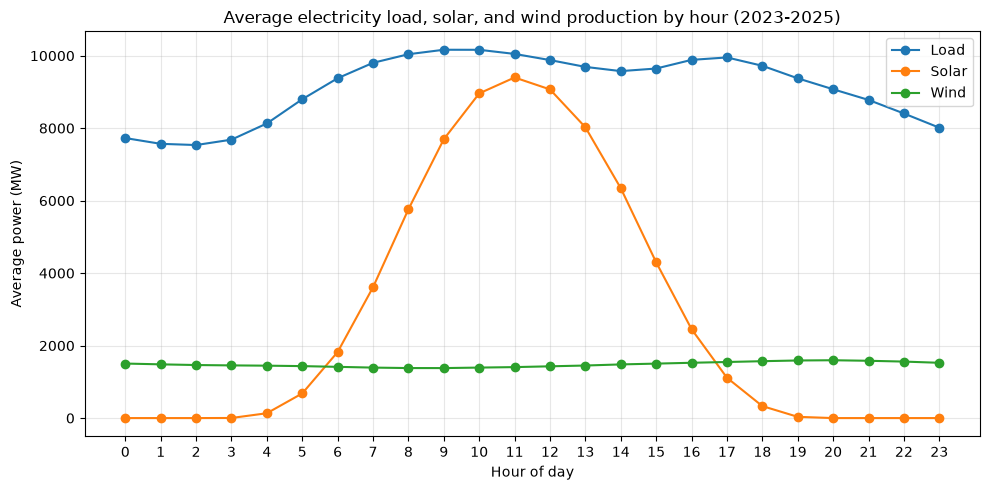

In [75]:
plt.figure(figsize=(10, 5))
plt.plot(hourly["hour"], hourly["avg_load"], label="Load", marker="o")
plt.plot(hourly["hour"], hourly["avg_solar"], label="Solar", marker="o")
plt.plot(hourly["hour"], hourly["avg_wind"], label="Wind", marker="o")

plt.xlabel("Hour of day")
plt.ylabel("Average power (MW)")
plt.title("Average electricity load, solar, and wind production by hour (2023-2025)")
plt.legend()
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../notebooks/hourly_pattern.png", dpi=150)
plt.show()

In [76]:
query= """
SELECT
    CASE
        WHEN month IN (12,1,2) THEN 'Winter'
        WHEN month IN (3,4,5) THEN 'Spring'
        WHEN month IN (6,7,8) THEN 'Summer'
        WHEN month IN (9,10,11) THEN 'Autumn'
    END AS season,
    ROUND(AVG(load_mw),1) AS avg_load,
    ROUND(AVG(solar_mw),1) AS avg_solar,
    ROUND(AVG(wind_mw),1) AS avg_wind,
    ROUND(AVG(renewable_share_pct),1) AS avg_renewable_share_pct
FROM energy
GROUP BY season
ORDER BY avg_load DESC
"""
seasonal = pd.read_sql(query,conn)
seasonal

,season,avg_load,avg_solar,avg_wind,avg_renewable_share_pct
0,Winter,10027.2,952.6,2024.5,29.6
1,Autumn,9159.9,2181.3,1592.6,40.0
2,Spring,8941.4,3714.9,1279.8,54.2
3,Summer,8396.7,4723.4,1034.3,64.8


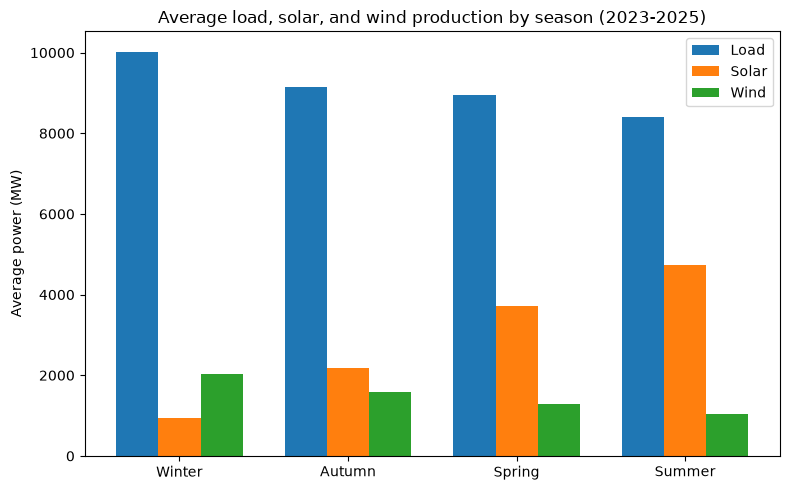

In [77]:
plt.figure(figsize=(8, 5))
x = seasonal["season"]
width = 0.25

plt.bar([i - width for i in range(len(x))], seasonal["avg_load"], width=width, label="Load")
plt.bar(range(len(x)), seasonal["avg_solar"], width=width, label="Solar")
plt.bar([i + width for i in range(len(x))], seasonal["avg_wind"], width=width, label="Wind")

plt.xticks(range(len(x)), x)
plt.ylabel("Average power (MW)")
plt.title("Average load, solar, and wind production by season (2023-2025)")
plt.legend()
plt.tight_layout()
plt.savefig("../notebooks/seasonal_pattern.png", dpi=150)
plt.show()

In [78]:
query = """
SELECT
    Datetime,
    load_mw,
    ROUND(AVG(load_mw) OVER (
        ORDER BY Datetime
        ROWS BETWEEN 671 PRECEDING AND CURRENT ROW
    ), 1) AS rolling_7day_avg
FROM energy
ORDER BY Datetime
"""

rolling = pd.read_sql(query, conn)
rolling.tail(10)


,Datetime,load_mw,rolling_7day_avg
105111,2025-12-30 21:45:00+00:00,9544.16,9578.1
105112,2025-12-30 22:00:00+00:00,9573.90,9577.9
105113,2025-12-30 22:15:00+00:00,9481.34,9577.8
105114,2025-12-30 22:30:00+00:00,9386.39,9577.7
105115,2025-12-30 22:45:00+00:00,9310.43,9577.8
105116,2025-12-30 23:00:00+00:00,9267.20,9578.2
105117,2025-12-30 23:15:00+00:00,9140.05,9578.6
105118,2025-12-30 23:30:00+00:00,9010.80,9579.1
105119,2025-12-30 23:45:00+00:00,8889.18,9579.6
105120,2025-12-31 00:00:00+00:00,8771.25,9579.9


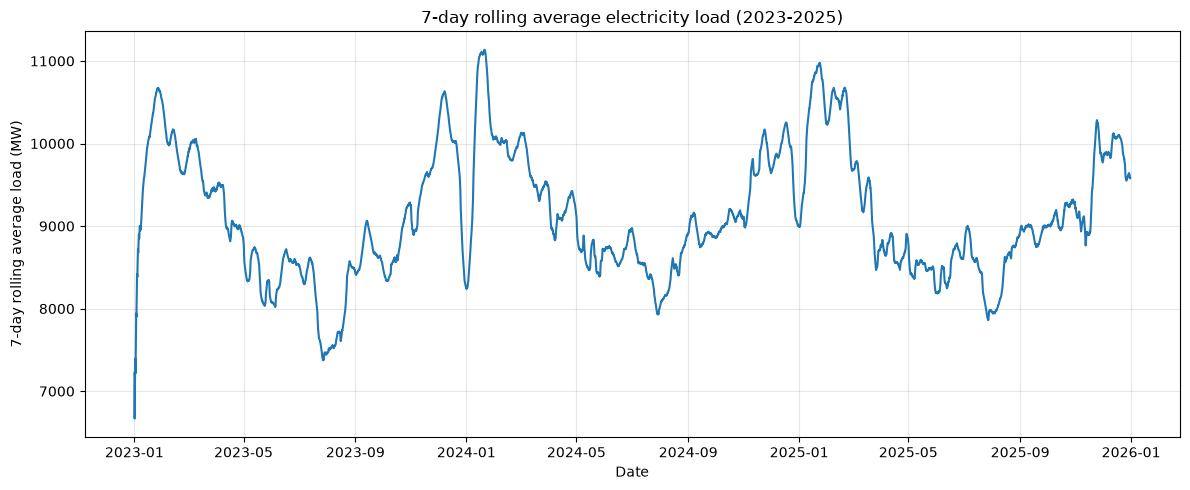

In [79]:
rolling["Datetime"] = pd.to_datetime(rolling["Datetime"])

plt.figure(figsize=(12, 5))
plt.plot(rolling["Datetime"], rolling["rolling_7day_avg"])

plt.xlabel("Date")
plt.ylabel("7-day rolling average load (MW)")
plt.title("7-day rolling average electricity load (2023-2025)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../notebooks/rolling_load.png", dpi=150)
plt.show()

In [80]:
conn.close()